In [67]:
import pandas as pd
import numpy as np
import cobra
import matplotlib.pyplot as plt

## Loading dataset

In [8]:
tcga_data_path = "/Users/valentinreateguirangel/dissertation_project/data/TCGA_LIver/TCGA-LIHC.star_tpm.tsv.gz.tsv"
tcga_df = pd.read_csv(tcga_data_path, sep="\t", index_col=0, compression="gzip")

## Data standarization 

In [16]:
# Remove vesrion numbers .00
tcga_df.index = tcga_df.index.str.split('.').str[0]

In [28]:
# Checkinf for duplicates
print(tcga_df.index.duplicated().sum())   

# Get the duplicated index values
duplicated_indices = tcga_df.index[tcga_df.index.duplicated()]

# Get all rows with duplicated indices (including the first occurrence)
duplicates_df = tcga_df.loc[tcga_df.index.isin(duplicated_indices)]

# Getting only duplicated rows for processing 
duplicate_rows = tcga_df.loc[duplicated_indices]

# Keeping only non "0"
non_zero_duplicates = duplicate_rows.loc[~(duplicate_rows == 0).all(axis=1)]

# Droping duplicates with all "0"
tcga_df_cleaned = tcga_df.drop(index= duplicated_indices)
tcga_df_cleaned = pd.concat([tcga_df_cleaned, non_zero_duplicates])

# Sorting out index
tcga_df_cleaned = tcga_df_cleaned.sort_index()

# Checking for duplicates
print(tcga_df_cleaned.index.duplicated().sum())    

44
0


## Relabelling TCGA columns

In [33]:
# Relabeling function
def label_tcga(col):
    try:
        parts = col.split('-')
        if len(parts) < 4:
            return f"TCGA_{col}"
        sample_code = parts[3][:2]
        condition = "Tumor" if sample_code == "01" else "Healthy" if sample_code == "11" else "Other"
        patient_id = parts[2]  
        return f"TCGA_{condition}_{patient_id}"
    except:
        return f"TCGA_Unknown_{col}"

In [36]:
tcga_labeled = tcga_df_cleaned.copy()
tcga_labeled.columns = [label_tcga(col) for col in tcga_labeled.columns]

## Z-scre normalization column-wise

In [76]:
# Column-wise Z-score normalization (within each sample)
z_scores = (tcga_labeled - tcga_labeled.mean(axis=0)) / tcga_labeled.std(axis=0)

In [78]:
# Binarizing 
z_bin = z_scores.copy()

# Binarize: +1, -1, 0
z_bin[z_scores >= 0.5] = 1
z_bin[z_scores <= -0.5] = -1
z_bin[(z_scores > -0.5) & (z_scores < 0.5)] = 0

In [80]:
# Split normalized data into tumor and healthy samples
z_tumor = z_bin.loc[:, z_scores.columns.str.contains("Tumor")]
z_healthy = z_bin.loc[:, z_scores.columns.str.contains("Healthy")]

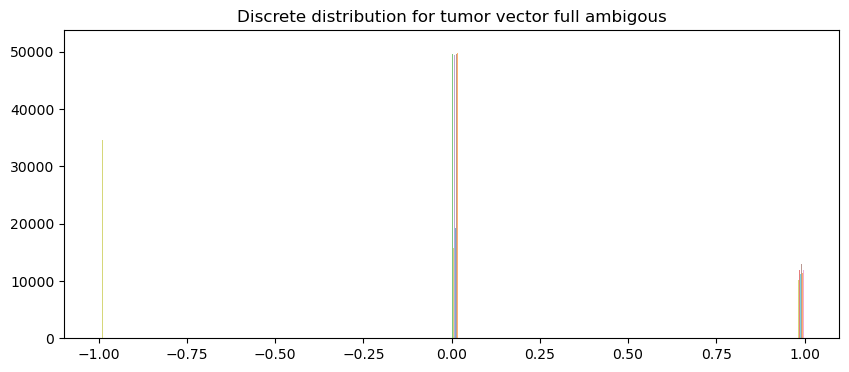

In [82]:
plt.figure(figsize=(10,4))
plt.hist(z_tumor, bins=100, alpha=0.6, label='Tumor')
plt.title("Discrete distribution for tumor vector full ambigous")
plt.show()

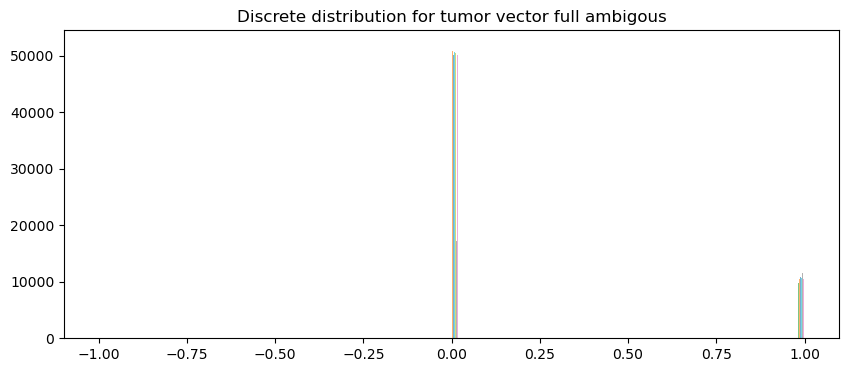

In [84]:
plt.figure(figsize=(10,4))
plt.hist(z_healthy, bins=100, alpha=0.6, label='Tumor')
plt.title("Discrete distribution for tumor vector full ambigous")
plt.show()

In [92]:
duplicated_samples = z_bin.columns[z_bin.columns.duplicated()].tolist()
print("Duplicated sample names:", duplicated_samples)

Duplicated sample names: ['TCGA_Other_AACA']


In [94]:
# Drop duplicated sample columns
z_bin = z_bin.loc[:, ~z_bin.columns.duplicated()]

In [96]:
import os
import pandas as pd

# Output directory
output_folder = "/Users/valentinreateguirangel/dissertation_project/notebooks/imat_vectors_fastcormics_per_sample"
os.makedirs(output_folder, exist_ok=True)

# Loop through each sample and export it
for sample in z_bin.columns:
    sample_vector = z_bin[sample]
    sample_df = pd.DataFrame({
        'GeneID': z_bin.index,
        'Expression': sample_vector
    })
    output_path = os.path.join(output_folder, f"{sample}_imat_vector.txt")
    sample_df.to_csv(output_path, sep="\t", index=False, header=False)

print("All sample vectors exported successfully!")

✅ All sample vectors exported successfully!
